# NIRDuino — Pipeline de procesamiento con MNE

Implementa el mismo flujo que `processing-all.ipynb` pero usando la API de MNE:

1. Carga datos desde TimescaleDB
2. Construye objeto `mne.io.RawArray` con canales `fnirs_cw_amplitude`
3. Separación canales largos (D3,D4,D6,D7,D8,D10,D13,D16, ~25 mm) y cortos LP (D1,D2,D5,D9,D11,D12,D14,D15, ~8-15 mm)
4. Montage personalizado con posiciones del probe NIRDuino
5. Scalp Coupling Index (calidad de señal)
6. Conversión a densidad óptica
7. Ley de Beer-Lambert Modificada → HbO₂ / Hb
8. Short-channel regression con detectores LP (separa señal cerebral de superficial)
9. Filtrado temporal
10. Anotaciones de estímulo → Epochs → Evoked response

---
**Instalación de dependencias:**
```bash
pip install mne matplotlib pandas psycopg2-binary
```

In [28]:
import json
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2
import mne
import mne_nirs
from pathlib import Path

mne.set_log_level('WARNING')
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ── Credenciales desde ~/.cogni/config.json (mismo que cogni-gui.py) ────────
_CONFIG_PATH = Path.home() / '.cogni' / 'config.json'
_cfg = json.loads(_CONFIG_PATH.read_text(encoding='utf-8'))
_db  = _cfg['db']

conn = psycopg2.connect(
    host=_db['host'],
    port=int(_db.get('port', 5432)),
    dbname=_db['dbname'],
    user=_db['user'],
    password=_db.get('password', ''),
)
print('Conectado a la base de datos.')

Conectado a la base de datos.


## 1. Carga de datos

In [29]:
SESSION_ID = '358ec10d-196e-4ce0-b2a3-f770e1e54d51'  # ← cambiar según sesión

df = pd.read_sql(
    f"SELECT * FROM frames WHERE session_id = '{SESSION_ID}' ORDER BY time_elapsed ASC",
    conn
)
print(f"Filas cargadas  : {len(df)}")
print(f"Duración        : {df['time_elapsed'].iloc[-1]:.1f} s")

# ── Regex para nombres válidos de par s{n}_d{n} ──────────────────────────────
_pair_re = re.compile(r'^(s\d+)_(d\d+)$')

def _parse_pair(pair):
    """Devuelve (src_key, det_key) o (None, None) si el nombre no es válido."""
    m = _pair_re.match(pair)
    return (m.group(1), m.group(2)) if m else (None, None)

# Todos los pares válidos presentes en la DB (cualquier detector)
_all_valid_pairs = sorted(set(
    col.replace('_740nm_rp', '')
    for col in df.columns
    if col.endswith('_740nm_rp') and _pair_re.match(col.replace('_740nm_rp', ''))
))

# Fuentes únicas con canal corto (LP)
sources_with_short = sorted(set(
    m.group(1)
    for col in df.columns
    if col.endswith('_740nm_lp')
    for m in [_pair_re.match(col.replace('_740nm_lp', ''))]
    if m
))

print(f"Pares totales en DB         : {len(_all_valid_pairs)}")
print(f"Fuentes con canal LP (corto): {len(sources_with_short)}")

/var/folders/31/xwhnlymx3311fjz1p3vjrp1h0000gn/T/ipykernel_45313/2472671030.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


Filas cargadas  : 864
Duración        : 190.9 s
Pares totales en DB         : 128
Fuentes con canal LP (corto): 8


## 2. Geometría del probe NIRDuino

Posiciones extraídas del esquema mecánico. **Origen = ⊕** (centro del probe).

```
y=73mm  D7(-40,73)   S7(-15,73)                    D4(+15,73)   S8(+40,73)
                     D5/LP7(-15,65)                              D2/LP8(+40,65)

y=25mm  D8(-65,25)   S4(-40,25)  D6(-15,25)         S5(+15,25)  D3(+40,25)   S6(+65,25)
                     D11/LP4(-40,15)                 D14/LP5(+15,15)          D1/LP6(+65,15)

y=0mm   S1(-65,0)    D10(-40,0)  S2(-15,0)    ⊕     D13(+15,0)  S3(+40,0)    D16(+65,0)
        D9/LP1(-65,8)            D12/LP2(-15,8)                  D15/LP3(+40,8)
```

**Mapeo DB ↔ físico:**
- Detectores LP (cortos): `d1`=D1/LP6, `d2`=D2/LP8, `d5`=D5/LP7, `d9`=D9/LP1,
  `d11`=D11/LP4, `d12`=D12/LP2, `d14`=D14/LP5, `d15`=D15/LP3
- Detectores RP (largos): `d3`=D3, `d4`=D4, `d6`=D6, `d7`=D7,
  `d8`=D8, `d10`=D10, `d13`=D13, `d16`=D16
- Pairing fuente→LP: s1→d9, s2→d12, s3→d15, s4→d11, s5→d14, s6→d1, s7→d5, s8→d2

Pares RP (largo) con posición conocida: 64


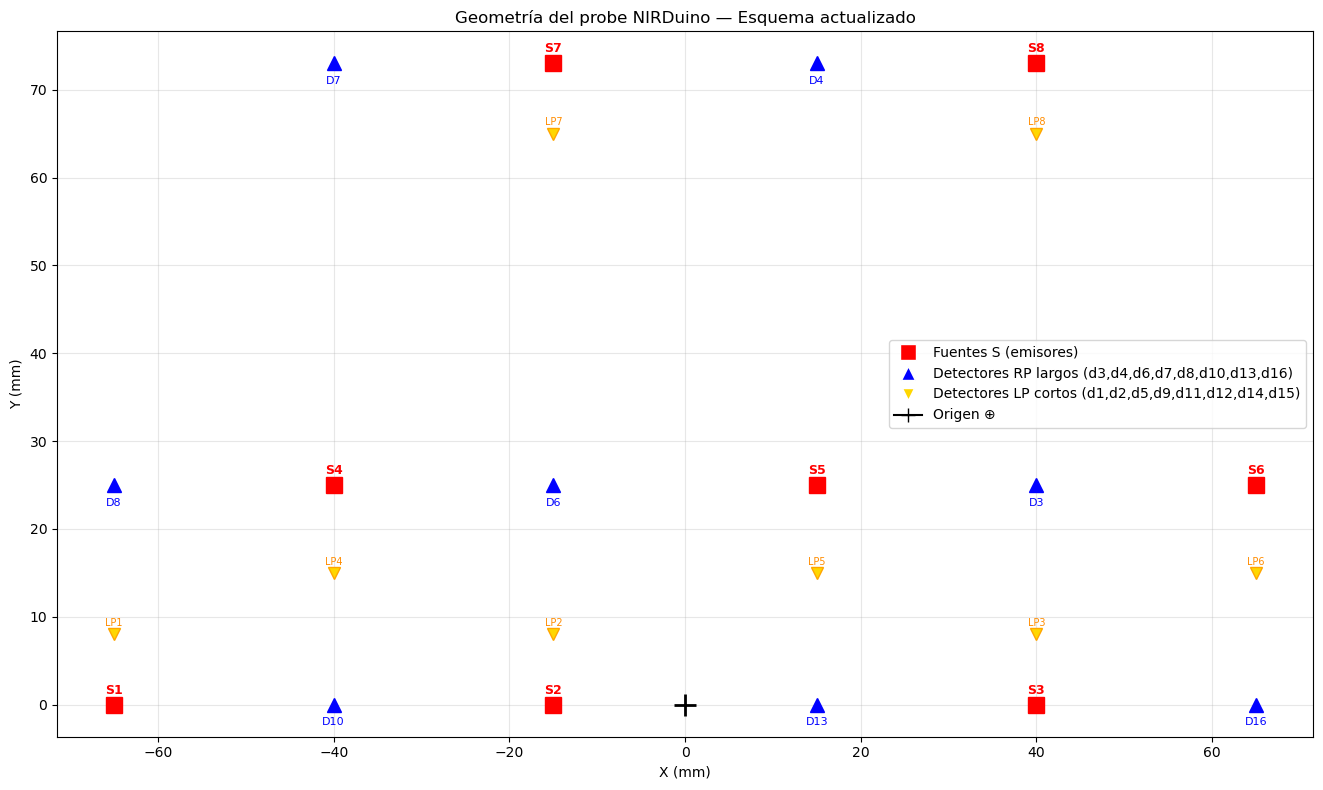


Distancias fuente-detector (canales RP):
  S1 D10: 25.0 mm
  S1 D13: 80.0 mm
  S1 D16: 130.0 mm
  S1 D3: 107.9 mm
  S1 D4: 108.3 mm
  S1 D6: 55.9 mm
  S1 D7: 77.2 mm
  S1 D8: 25.0 mm
  S2 D10: 25.0 mm
  S2 D13: 30.0 mm
  S2 D16: 80.0 mm
  S2 D3: 60.4 mm
  S2 D4: 78.9 mm
  S2 D6: 25.0 mm
  S2 D7: 77.2 mm
  S2 D8: 55.9 mm
  S3 D10: 80.0 mm
  S3 D13: 25.0 mm
  S3 D16: 25.0 mm
  S3 D3: 25.0 mm
  S3 D4: 77.2 mm
  S3 D6: 60.4 mm
  S3 D7: 108.3 mm
  S3 D8: 107.9 mm
  S4 D10: 25.0 mm
  S4 D13: 60.4 mm
  S4 D16: 107.9 mm
  S4 D3: 80.0 mm
  S4 D4: 73.0 mm
  S4 D6: 25.0 mm
  S4 D7: 48.0 mm
  S4 D8: 25.0 mm
  S5 D10: 60.4 mm
  S5 D13: 25.0 mm
  S5 D16: 55.9 mm
  S5 D3: 25.0 mm
  S5 D4: 48.0 mm
  S5 D6: 30.0 mm
  S5 D7: 73.0 mm
  S5 D8: 80.0 mm
  S6 D10: 107.9 mm
  S6 D13: 55.9 mm
  S6 D16: 25.0 mm
  S6 D3: 25.0 mm
  S6 D4: 69.3 mm
  S6 D6: 80.0 mm
  S6 D7: 115.5 mm
  S6 D8: 130.0 mm
  S7 D10: 77.2 mm
  S7 D13: 78.9 mm
  S7 D16: 108.3 mm
  S7 D3: 73.0 mm
  S7 D4: 30.0 mm
  S7 D6: 48.0 mm
  S7 D7: 

In [30]:
# ── Posiciones en mm (X, Y, Z=0 → probe plano), origen = ⊕ ──────────────────
SOURCE_POS_MM = {
    's1': np.array([-65.0,  0.0, 0.0]),  # S1 — fila inferior izquierda
    's2': np.array([-15.0,  0.0, 0.0]),  # S2 — fila inferior centro-izq
    's3': np.array([ 40.0,  0.0, 0.0]),  # S3 — fila inferior centro-der
    's4': np.array([-40.0, 25.0, 0.0]),  # S4 — fila media izquierda
    's5': np.array([ 15.0, 25.0, 0.0]),  # S5 — fila media centro
    's6': np.array([ 65.0, 25.0, 0.0]),  # S6 — fila media derecha
    's7': np.array([-15.0, 73.0, 0.0]),  # S7 — fila superior centro-izq
    's8': np.array([ 40.0, 73.0, 0.0]),  # S8 — fila superior centro-der
}

# Detectores RP de separación larga — DB columns d3,d4,d6,d7,d8,d10,d13,d16
LONG_DET_POS_MM = {
    'd3':  np.array([ 40.0, 25.0, 0.0]),  # D3  — fila media der
    'd4':  np.array([ 15.0, 73.0, 0.0]),  # D4  — fila superior centro
    'd6':  np.array([-15.0, 25.0, 0.0]),  # D6  — fila media centro
    'd7':  np.array([-40.0, 73.0, 0.0]),  # D7  — fila superior izq
    'd8':  np.array([-65.0, 25.0, 0.0]),  # D8  — fila media izq
    'd10': np.array([-40.0,  0.0, 0.0]),  # D10 — fila inferior centro-izq
    'd13': np.array([ 15.0,  0.0, 0.0]),  # D13 — fila inferior centro-der
    'd16': np.array([ 65.0,  0.0, 0.0]),  # D16 — fila inferior der
}

# Detectores LP de separación corta — keyed by DB detector column (not source)
SHORT_DET_POS_MM = {
    'd9':  np.array([-65.0,  8.0, 0.0]),  # D9/LP1  — junto a S1
    'd12': np.array([-15.0,  8.0, 0.0]),  # D12/LP2 — junto a S2
    'd15': np.array([ 40.0,  8.0, 0.0]),  # D15/LP3 — junto a S3
    'd11': np.array([-40.0, 15.0, 0.0]),  # D11/LP4 — junto a S4
    'd14': np.array([ 15.0, 15.0, 0.0]),  # D14/LP5 — junto a S5
    'd1':  np.array([ 65.0, 15.0, 0.0]),  # D1/LP6  — junto a S6
    'd5':  np.array([-15.0, 65.0, 0.0]),  # D5/LP7  — junto a S7
    'd2':  np.array([ 40.0, 65.0, 0.0]),  # D2/LP8  — junto a S8
}

# Mapeo explícito fuente → detector LP adyacente
SOURCE_TO_SHORT_DET = {
    's1': 'd9',  's2': 'd12', 's3': 'd15', 's4': 'd11',
    's5': 'd14', 's6': 'd1',  's7': 'd5',  's8': 'd2',
}

SHORT_DET_LP_LABEL = {
    'd9': 'LP1', 'd12': 'LP2', 'd15': 'LP3', 'd11': 'LP4',
    'd14': 'LP5', 'd1': 'LP6', 'd5': 'LP7', 'd2': 'LP8',
}

# Pares con detector largo conocido
long_pairs = [
    p for p in _all_valid_pairs
    if _parse_pair(p)[1] in LONG_DET_POS_MM
]
print(f"Pares RP (largo) con posición conocida: {len(long_pairs)}")

# ── Visualización del probe ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))
for name, pos in SOURCE_POS_MM.items():
    ax.plot(pos[0], pos[1], 'rs', markersize=12)
    ax.annotate(name.upper(), (pos[0], pos[1]), textcoords='offset points',
                xytext=(0, 8), ha='center', color='red', fontsize=9, fontweight='bold')
for det_key, pos in LONG_DET_POS_MM.items():
    ax.plot(pos[0], pos[1], 'b^', markersize=10)
    ax.annotate(det_key.upper(), (pos[0], pos[1]), textcoords='offset points',
                xytext=(0, -15), ha='center', color='blue', fontsize=8)
for det_key, pos in SHORT_DET_POS_MM.items():
    label = SHORT_DET_LP_LABEL.get(det_key, det_key)
    ax.plot(pos[0], pos[1], 'v', markersize=9, color='gold', markeredgecolor='orange')
    ax.annotate(label, (pos[0], pos[1]), textcoords='offset points',
                xytext=(0, 6), ha='center', color='darkorange', fontsize=7)
ax.plot(0, 0, 'k+', markersize=16, markeredgewidth=2)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)')
ax.set_title('Geometría del probe NIRDuino — Esquema actualizado')
ax.legend(handles=[
    plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='red',    markersize=11, label='Fuentes S (emisores)'),
    plt.Line2D([0],[0], marker='^', color='w', markerfacecolor='blue',   markersize=10, label='Detectores RP largos (d3,d4,d6,d7,d8,d10,d13,d16)'),
    plt.Line2D([0],[0], marker='v', color='w', markerfacecolor='gold',   markersize=9,  label='Detectores LP cortos (d1,d2,d5,d9,d11,d12,d14,d15)'),
    plt.Line2D([0],[0], marker='+', color='k', markersize=10,             label='Origen ⊕'),
])
plt.tight_layout(); plt.show()

# ── Distancias fuente-detector ────────────────────────────────────────────────
print("\nDistancias fuente-detector (canales RP):")
for pair in long_pairs:
    src_key, det_key = _parse_pair(pair)
    dist = np.linalg.norm(SOURCE_POS_MM[src_key] - LONG_DET_POS_MM[det_key])
    print(f"  {src_key.upper()} {det_key.upper()}: {dist:.1f} mm")

print("\nDistancias fuente-detector (canales LP — cortos):")
for src_key, det_key_lp in SOURCE_TO_SHORT_DET.items():
    dist = np.linalg.norm(SOURCE_POS_MM[src_key] - SHORT_DET_POS_MM[det_key_lp])
    print(f"  {src_key.upper()} → {det_key_lp.upper()} ({SHORT_DET_LP_LABEL[det_key_lp]}): {dist:.1f} mm")

## 3. Construcción del objeto MNE Raw

Canales largos: `_rp` de D3,D4,D6,D7,D8,D10,D13,D16 × 2 wavelengths  
Canales cortos: detectores LP (D1,D2,D5,D9,D11,D12,D14,D15) × 2 wavelengths (usados para short-channel regression)

In [31]:
WAVELENGTHS = [740, 850]

# ── Frecuencia de muestreo real ───────────────────────────────────────────────
t_arr = df['time_elapsed'].values
sfreq = (len(t_arr) - 1) / (t_arr[-1] - t_arr[0])
print(f"Frecuencia de muestreo: {sfreq:.2f} Hz")

data_arrays = []
ch_names    = []
src_locs    = []
det_locs    = []
is_short    = []

# ── Canales largos (RP, D3,D4,D6,D7,D8,D10,D13,D16) ─────────────────────────
for pair in long_pairs:
    src_key, det_key = _parse_pair(pair)
    mne_base = f'S{src_key[1:]}_D{det_key[1:]}'
    for wl in WAVELENGTHS:
        col = f'{pair}_{wl}nm_rp'
        if col not in df.columns:
            continue
        data_arrays.append(df[col].values.astype(float))
        ch_names.append(f'{mne_base} {wl}')
        src_locs.append(SOURCE_POS_MM[src_key] / 1000.0)
        det_locs.append(LONG_DET_POS_MM[det_key] / 1000.0)
        is_short.append(False)

# ── Canales cortos (LP) — pairing explícito via SOURCE_TO_SHORT_DET ──────────
for src_key in sources_with_short:
    det_key_lp = SOURCE_TO_SHORT_DET.get(src_key)
    if det_key_lp is None or det_key_lp not in SHORT_DET_POS_MM:
        continue
    lp_col_base = f'{src_key}_{det_key_lp}_740nm_lp'
    if lp_col_base not in df.columns:
        continue
    src_num = src_key[1:]
    mne_base = f'S{src_num}_D{det_key_lp[1:]}'
    for wl in WAVELENGTHS:
        col = f'{src_key}_{det_key_lp}_{wl}nm_lp'
        if col not in df.columns:
            continue
        data_arrays.append(df[col].values.astype(float))
        ch_names.append(f'{mne_base} {wl}')
        src_locs.append(SOURCE_POS_MM[src_key] / 1000.0)
        det_locs.append(SHORT_DET_POS_MM[det_key_lp] / 1000.0)
        is_short.append(True)

# ── Crear MNE Info y RawArray ─────────────────────────────────────────────────
n_long  = sum(not s for s in is_short)
n_short = sum(is_short)

info = mne.create_info(
    ch_names=ch_names,
    sfreq=sfreq,
    ch_types=['fnirs_cw_amplitude'] * len(ch_names)
)

with info._unlock():
    for i, (sp, dp) in enumerate(zip(src_locs, det_locs)):
        info['chs'][i]['loc'][0:3] = (sp + dp) / 2.0  # midpoint
        info['chs'][i]['loc'][3:6] = sp                # emisor
        info['chs'][i]['loc'][6:9] = dp                # detector
        info['chs'][i]['loc'][9]   = float(ch_names[i].split(' ')[1])  # wavelength

raw_intensity = mne.io.RawArray(np.array(data_arrays), info, verbose=False)

print(f"\nRaw creado: {raw_intensity.info['nchan']} canales × {len(t_arr)} muestras")
print(f"  Canales largos (RP): {n_long}")
print(f"  Canales cortos (LP): {n_short}")
print(f"  sfreq: {raw_intensity.info['sfreq']:.2f} Hz")

# Verificar distancias calculadas por MNE
dists = mne.preprocessing.nirs.source_detector_distances(raw_intensity.info) * 1000  # m → mm
long_dists  = dists[~np.array(is_short)]
short_dists = dists[ np.array(is_short)]
print(f"\nDistancias canales largos  : {long_dists.min():.1f}–{long_dists.max():.1f} mm")
print(f"Distancias canales cortos  : {short_dists.min():.1f}–{short_dists.max():.1f} mm")

Frecuencia de muestreo: 4.54 Hz

Raw creado: 144 canales × 864 muestras
  Canales largos (RP): 128
  Canales cortos (LP): 16
  sfreq: 4.54 Hz

Distancias canales largos  : 25.0–130.0 mm
Distancias canales cortos  : 8.0–10.0 mm


## 4. Conversión a Densidad Óptica

In [32]:
raw_od = mne.preprocessing.nirs.optical_density(raw_intensity)

print(f"Rango OD: [{raw_od.get_data().min():.4f}, {raw_od.get_data().max():.4f}]")
raw_od.plot(n_channels=10, duration=60, scalings='auto',
            title='Densidad óptica (primeros 60 s)', show=True)

Rango OD: [-1.0510, 0.7554]


<mne_qt_browser._pg_figure.MNEQtBrowser(0x310bd8240) at 0x30fed3f40>

## 5. Scalp Coupling Index — Calidad de señal

Canales largos con SCI < 0.5: 110
  S1_D10 740: 0.349
  S1_D10 850: 0.349
  S1_D13 740: -0.148
  S1_D13 850: -0.148
  S1_D16 740: 0.049
  S1_D16 850: 0.049
  S1_D3 740: 0.035
  S1_D3 850: 0.035
  S1_D4 740: -0.045
  S1_D4 850: -0.045
  S1_D6 740: -0.022
  S1_D6 850: -0.022
  S1_D8 740: -0.034
  S1_D8 850: -0.034
  S2_D10 740: 0.309
  S2_D10 850: 0.309
  S2_D13 740: -0.259
  S2_D13 850: -0.259
  S2_D16 740: 0.203
  S2_D16 850: 0.203
  S2_D3 740: 0.026
  S2_D3 850: 0.026
  S2_D4 740: -0.204
  S2_D4 850: -0.204
  S2_D6 740: -0.098
  S2_D6 850: -0.098
  S2_D7 740: 0.434
  S2_D7 850: 0.434
  S2_D8 740: -0.018
  S2_D8 850: -0.018
  S3_D10 740: 0.433
  S3_D10 850: 0.433
  S3_D16 740: 0.022
  S3_D16 850: 0.022
  S3_D3 740: 0.367
  S3_D3 850: 0.367
  S3_D4 740: 0.296
  S3_D4 850: 0.296
  S3_D6 740: 0.072
  S3_D6 850: 0.072
  S3_D8 740: 0.050
  S3_D8 850: 0.050
  S4_D10 740: 0.434
  S4_D10 850: 0.434
  S4_D16 740: 0.001
  S4_D16 850: 0.001
  S4_D3 740: 0.165
  S4_D3 850: 0.165
  S4_D4 740: 0.238

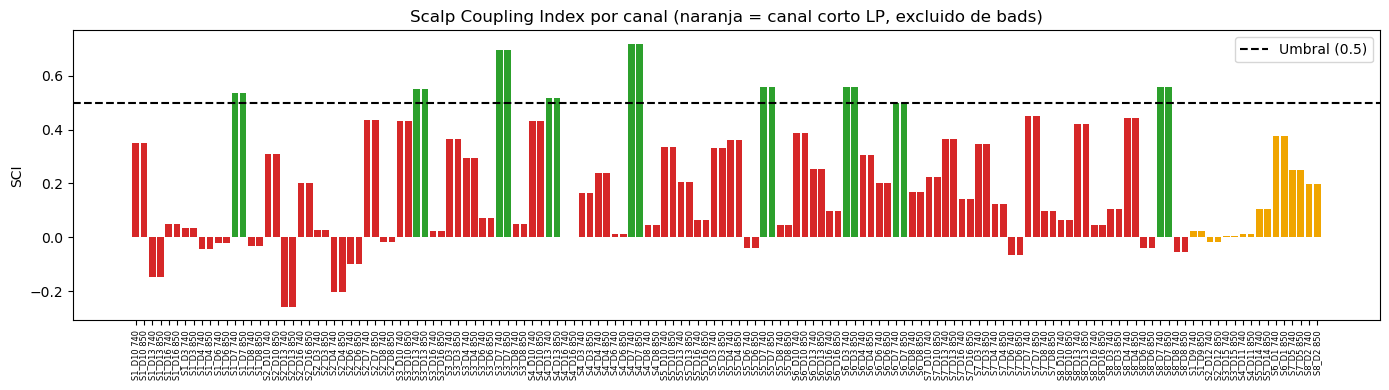

In [33]:
sci = mne.preprocessing.nirs.scalp_coupling_index(raw_od)

SCI_THRESHOLD = 0.5

# Only mark long channels as bad — short channels have low SCI by design
# (they don't see the cardiac pulse) and must remain available for SSR
dists_for_sci = mne.preprocessing.nirs.source_detector_distances(raw_od.info)
bad_channels = [
    ch for ch, s, d in zip(raw_od.ch_names, sci, dists_for_sci)
    if s < SCI_THRESHOLD and d >= 0.015
]

print(f"Canales largos con SCI < {SCI_THRESHOLD}: {len(bad_channels)}")
for ch in bad_channels:
    print(f"  {ch}: {sci[raw_od.ch_names.index(ch)]:.3f}")

raw_od.info['bads'] = bad_channels

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(sci)), sci,
       color=['#d62728' if s < SCI_THRESHOLD and d >= 0.015 else
              '#f0a500' if d < 0.015 else
              '#2ca02c'
              for s, d in zip(sci, dists_for_sci)])
ax.axhline(SCI_THRESHOLD, color='k', linestyle='--', label=f'Umbral ({SCI_THRESHOLD})')
ax.set_xticks(range(len(sci)))
ax.set_xticklabels(raw_od.ch_names, rotation=90, fontsize=6)
ax.set_ylabel('SCI'); ax.set_title('Scalp Coupling Index por canal (naranja = canal corto LP, excluido de bads)')
ax.legend(); plt.tight_layout(); plt.show()

## 6. Short-Channel Regression

Los detectores LP (~8-15 mm) capturan señal superficial. La regresión se aplica sobre OD antes de Beer-Lambert, que es el orden correcto según mne-nirs.

In [34]:
SHORT_CH_THRESHOLD_M = 0.015  # 15 mm

dists_od = mne.preprocessing.nirs.source_detector_distances(raw_od.info)
n_short_od = (dists_od < SHORT_CH_THRESHOLD_M).sum()
print(f"Canales cortos identificados en raw_od: {n_short_od}")

if n_short_od > 0:
    raw_od_ssr = mne_nirs.signal_enhancement.short_channel_regression(
        raw_od, max_dist=SHORT_CH_THRESHOLD_M
    )
    print("Short-channel regression aplicada sobre OD.")
else:
    raw_od_ssr = raw_od
    print("Sin canales cortos detectados — regresión omitida.")
    print("  Verificar SHORT_DET_POS_MM: las distancias LP deben ser < 15 mm.")

print(f"Canales en raw_od_ssr: {raw_od_ssr.info['nchan']}")

Canales cortos identificados en raw_od: 16
Short-channel regression aplicada sobre OD.
Canales en raw_od_ssr: 144


## 7. Ley de Beer-Lambert Modificada → HbO₂ / Hb

In [35]:
# ppf = Partial Path-length Factor (equivalente al DPF del pipeline manual)
# Valores del paper para corteza frontal: DPF_740=6.25, DPF_850=4.89
raw_haemo = mne.preprocessing.nirs.beer_lambert_law(raw_od_ssr, ppf=6.0)

n_hbo = len(mne.pick_types(raw_haemo.info, fnirs='hbo'))
n_hbr = len(mne.pick_types(raw_haemo.info, fnirs='hbr'))
print(f"HbO₂ (hbo): {n_hbo}  |  Hb (hbr): {n_hbr}")

# Conservar solo canales largos para el análisis downstream
dists_haemo = mne.preprocessing.nirs.source_detector_distances(raw_haemo.info)
long_ch_names = [ch for ch, d in zip(raw_haemo.ch_names, dists_haemo)
                 if d >= SHORT_CH_THRESHOLD_M]
raw_long = raw_haemo.copy().pick(long_ch_names)
print(f"Canales largos para análisis: {len(raw_long.ch_names)}")

HbO₂ (hbo): 17  |  Hb (hbr): 17
Canales largos para análisis: 128


## 8. Filtrado temporal

In [36]:
# Paso-banda hemodinámico: 0.01–0.5 Hz
# Elimina deriva lenta (<0.01 Hz) y ruido cardíaco (>0.5 Hz)
raw_filt = raw_long.copy().filter(
    l_freq=0.01, h_freq=0.5,
    method='iir', iir_params=dict(order=4, ftype='butter'),
)
print("Filtro paso-banda 0.01–0.5 Hz aplicado.")

hbo_picks = mne.pick_types(raw_filt.info, fnirs='hbo')
raw_filt.plot(picks=hbo_picks[:6], duration=90, scalings='auto',
              title='HbO₂ filtrado — primeros 6 canales', show=True)

Filtro paso-banda 0.01–0.5 Hz aplicado.


<mne_qt_browser._pg_figure.MNEQtBrowser(0x31293c330) at 0x30fed34c0>

## 9. Anotaciones de estímulo

In [37]:
stim  = df['stimulus'].values
times = df['time_elapsed'].values

onsets, durations, desc = [], [], []
in_stim = False

for t_i, s_i in zip(times, stim):
    if s_i == 1 and not in_stim:
        stim_start = t_i;  in_stim = True
    elif s_i == 0 and in_stim:
        onsets.append(stim_start);  durations.append(t_i - stim_start)
        desc.append('stimulus');    in_stim = False

if in_stim:   # sesión termina con estímulo activo
    onsets.append(stim_start);  durations.append(times[-1] - stim_start)
    desc.append('stimulus')

raw_filt.set_annotations(mne.Annotations(onsets, durations, desc))

print(f"Bloques de estímulo: {len(onsets)}")
for i, (t0, dur) in enumerate(zip(onsets, durations)):
    print(f"  Bloque {i+1}: {t0:.2f} s — duración {dur:.2f} s")

Bloques de estímulo: 2
  Bloque 1: 44.10 s — duración 28.71 s
  Bloque 2: 126.75 s — duración 49.38 s


## 10. Epochs y Evoked response

In [38]:
TMIN, TMAX = -5.0, 30.0

events, event_id = mne.events_from_annotations(raw_filt)
epochs = mne.Epochs(
    raw_filt, events, event_id=event_id,
    tmin=TMIN, tmax=TMAX,
    baseline=(TMIN, 0.0),
    reject_by_annotation=False,
    preload=True, verbose=False,
)
print(f"Epochs: {len(epochs)} trials × {epochs.get_data().shape[2]} muestras")

Epochs: 2 trials × 160 muestras


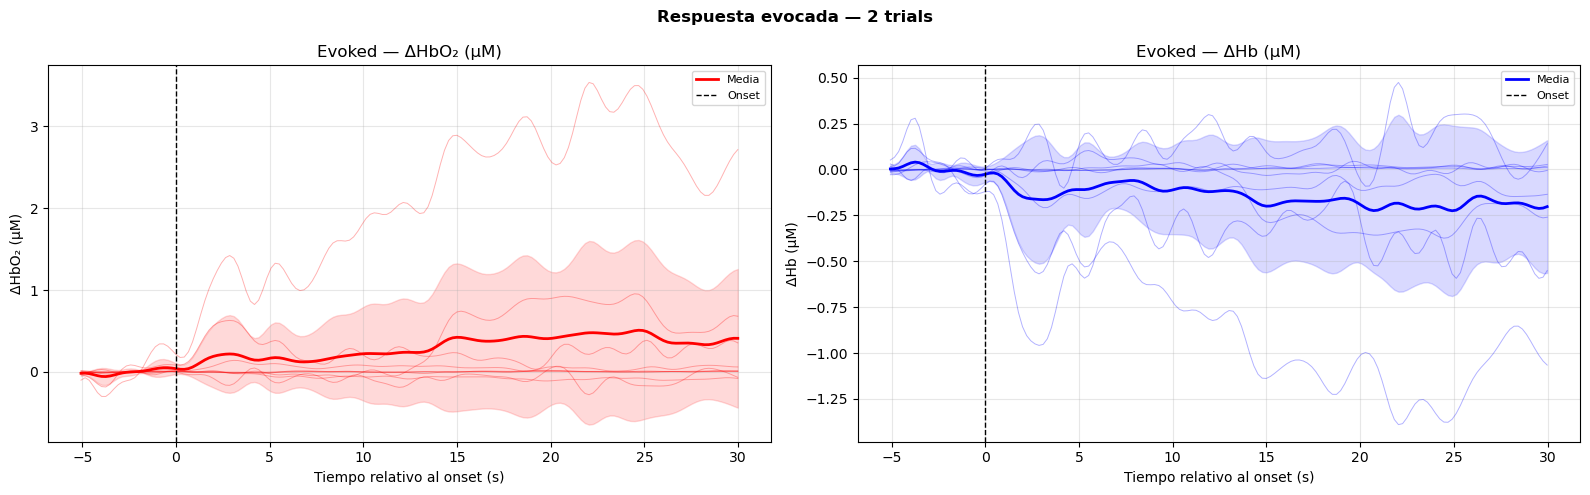

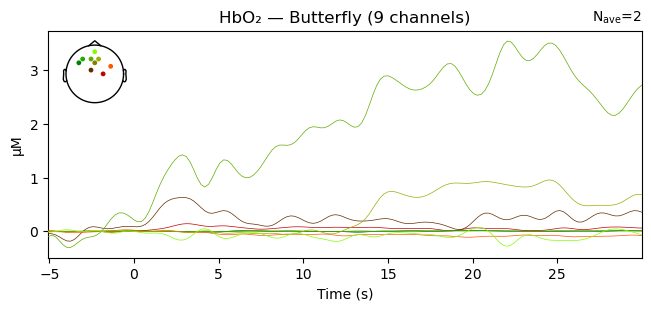

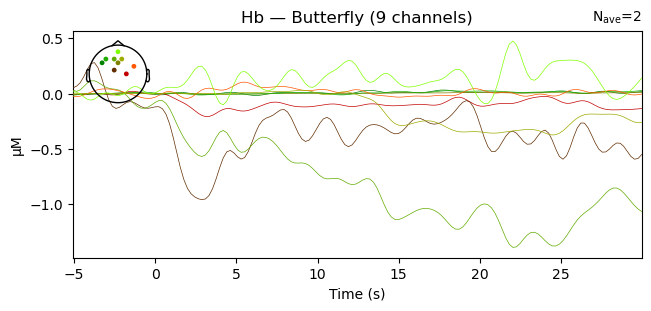

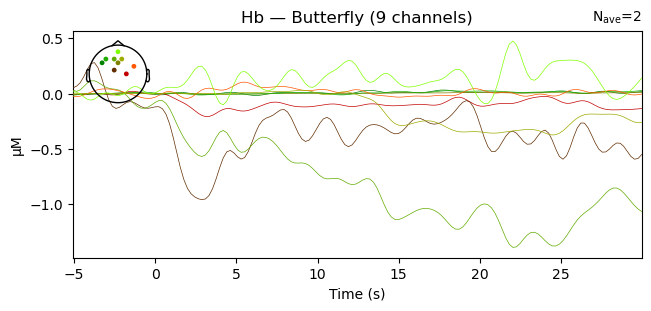

In [40]:
evoked   = epochs.average()
hbo_picks = mne.pick_types(evoked.info, fnirs='hbo')
hbr_picks = mne.pick_types(evoked.info, fnirs='hbr')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, picks, label, color in [
    (axes[0], hbo_picks, 'ΔHbO₂ (μM)', 'red'),
    (axes[1], hbr_picks, 'ΔHb (μM)',   'blue'),
]:
    data = evoked.data[picks] * 1e6   # M → μM
    t    = evoked.times
    for s in data:
        ax.plot(t, s, alpha=0.3, color=color, linewidth=0.7)
    mean = data.mean(axis=0)
    std  = data.std(axis=0)
    ax.plot(t, mean, color=color, linewidth=2, label='Media')
    ax.fill_between(t, mean - std, mean + std, alpha=0.15, color=color)
    ax.axvline(0, color='k', linestyle='--', linewidth=1, label='Onset')
    ax.set_xlabel('Tiempo relativo al onset (s)')
    ax.set_ylabel(label);  ax.set_title(f'Evoked — {label}')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(f'Respuesta evocada — {len(epochs)} trials', fontweight='bold')
plt.tight_layout(); plt.show()

# Butterfly — MNE 1.x usa title= (singular)
evoked.plot(picks=hbo_picks, spatial_colors=True,
            titles='HbO₂ — Butterfly', show=True, time_unit='s')
evoked.plot(picks=hbr_picks, spatial_colors=True,
            titles='Hb — Butterfly',   show=True, time_unit='s')

## 11. Topomaps

Pico HbO₂ a t = 24.69 s


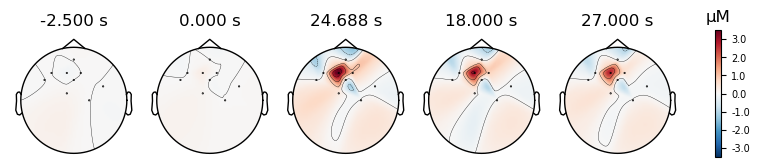

In [42]:
peak_time = evoked.times[np.argmax(evoked.data[hbo_picks].mean(axis=0))]
print(f"Pico HbO₂ a t = {peak_time:.2f} s")

try:
    evoked.plot_topomap(
        times=[TMIN/2, 0.0, peak_time, TMAX * 0.6, TMAX * 0.9],
        ch_type='hbo',
        show=True,
    )
except Exception as e:
    print(f"Topomap omitido: {e}")
    print("Verificar que las posiciones del montage sean correctas.")

## 12. Guardar a .fif (opcional)

In [ ]:
OUT_DIR = Path.home() / '.cogni' / 'processed'
OUT_DIR.mkdir(parents=True, exist_ok=True)
out_path = OUT_DIR / f'{SESSION_ID[:8]}_fnirs_haemo_raw.fif'
raw_filt.save(out_path, overwrite=True)
print(f"Guardado en: {out_path}")
# raw_loaded = mne.io.read_raw_fif(out_path, preload=True)